[2026-03-20 Fiddler](https://thefiddler.substack.com/p/can-you-trace-the-locus)
====================

Fiddler
-------
The loop will be a circle.  Let $r$ be the loop's radius.

Let $2\theta$ be the angle between the two radii from the center of the unit circle to the
points where the string stops being connected to the unit circle.  Then $r^2 = 1 + \tan^2\theta$,
so the area is $\pi(1 + \tan^2\theta)$.

The length of the string is then $2\pi - 2\theta + 2\tan\theta = 10$.  I couldn't find an exact
solution.  Numerically, the area inside the loop is approximately 33.70.

In [1]:
theta = var('theta')
solve(2*pi - 2*theta + 2*tan(theta) == 10, theta)

[theta == pi + tan(theta) - 5]

In [2]:
t = find_root(2*pi - 2*theta + 2*tan(theta) - 10, 0, pi/2)
numerical_approx(pi*(1 + tan(t)^2))

33.7022675391995

Extra credit
------------
From symmetry, calculate one quarter of the area, then multiply by four.

Let the circles be centered at $(-1,0)$ and $(1,0)$.  Break up the
quarter-loop into two pieces.  One where the drag point goes from $(0,y_1)$
to $(x_2,1)$, where the segments of the string from the drag point connect
to different circles.  The other where the drag point goes from $(x_2,1)$ to
$(x_3,0)$, where the segments of the string from the drag point both connect
to the circle on the right.

Consider the first piece.  Let $(x,y)$ be the drag point.  Let the connection
points be $(x_L,y_L) = (-1-\sin\theta_L,\cos\theta_L)$ and
$(x_R,y_R) = (1+\sin\theta_R,\cos\theta_R)$.

The length of the string is $2+2\pi-\theta_L-\theta_R
+\sqrt{(x-x_L)^2+(y-y_L)^2}+\sqrt{(x-x_R)^2+(y-y_R)^2} = 14$.

I resorted to numerically integrating a function that numerically finds $y$ for
a given $x$ to get the area in this case.

In [3]:
x,y = var("x,y")
alpha_L = arccos(1/sqrt((x+1)^2+y^2))
beta_L = arctan((x+1)/y)
theta_L = alpha_L - beta_L
x_L = -1-sin(theta_L)
y_L = cos(theta_L)
alpha_R = arccos(1/sqrt((x-1)^2+y^2))
beta_R = arctan((1-x)/y)
theta_R = alpha_R - beta_R
x_R = 1+sin(theta_R)
y_R = cos(theta_R)
L1(x,y) = 2 + 2*pi - theta_L - theta_R + sqrt((x-x_L)^2 + (y-y_L)^2) + sqrt((x-x_R)^2 + (y-y_R)^2)

In [4]:
y1 = find_root(L1(0,y) - 14, 1, 5)
y1

3.930994056877134

In [5]:
x2 = find_root(L1(x,1) - 14, 1, 5)
x2

4.118936508577619

In [6]:
a1 = numerical_integral(lambda x: find_root(L1(x,y) - 14, 1, 4), 0, x2)
a1

(12.986412999694931, 1.4417814719552758e-13)

An illustration of $x, y, \alpha_L, \beta_L, \theta_L, x_L, y_L,
\alpha_R, \beta_R, \theta_R, x_R, y_R$, used to calculate $L_1(x,y)$.

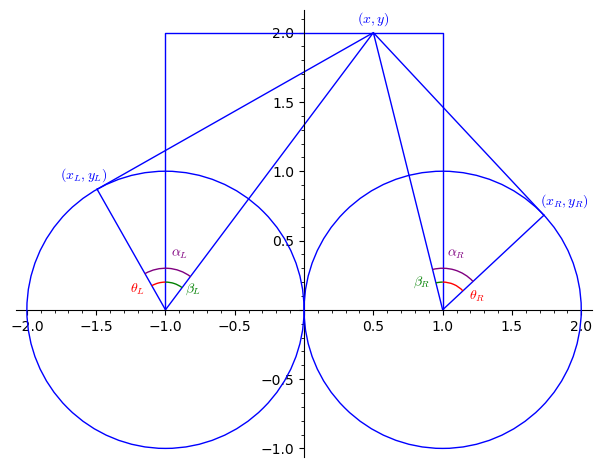

In [7]:
xp, yp = 1/2, 2
xl, yl = x_L.substitute(x==xp,y==yp), y_L.substitute(x==xp,y==yp)
al, bl, tl = alpha_L.substitute(x==xp,y==yp), beta_L.substitute(x==xp,y==yp), theta_L.substitute(x==xp,y==yp)
xr, yr = x_R.substitute(x==xp,y==yp), y_R.substitute(x==xp,y==yp)
ar, br, tr = alpha_R.substitute(x==xp,y==yp), beta_R.substitute(x==xp,y==yp), theta_R.substitute(x==xp,y==yp)
(circle((-1,0),1)+circle((1,0),1)
 +line([(xl,yl),(xp,yp),(-1,0),(xl,yl)])
 +line([(-1,0),(-1,yp),(xp,yp)])
 +line([(xr,yr),(xp,yp),(1,0),(xr,yr)])
 +line([(1,0),(1,yp),(xp,yp)])
 +arc((-1,0),0.2,sector=(pi/2,pi/2+tl),color="red")
 +text(r"$\theta_L$",(-1.2,0.15),color="red")
 +arc((-1,0),0.2,sector=(pi/2-bl,pi/2),color="green")
 +text(r"$\beta_L$",(-0.8,0.15),color="green")
 +arc((-1,0),0.3,sector=(pi/2-bl,pi/2-bl+al),color="purple")
 +text(r"$\alpha_L$",(-0.9,0.4),color="purple")
 +arc((1,0),0.2,sector=(pi/2,pi/2-tr),color="red")
 +text(r"$\theta_R$",(1.25,0.1),color="red")
 +arc((1,0),0.2,sector=(pi/2,pi/2+br),color="green")
 +text(r"$\beta_R$",(0.85,0.2),color="green")
 +arc((1,0),0.3,sector=(pi/2+br,pi/2+br-ar),color="purple")
 +text(r"$\alpha_R$",(1.1,0.4),color="purple")
 +text(r"$(x,y)$",(xp,yp+0.1))
 +text(r"$(x_L,y_L)$",(xl-0.1,yl+0.1))
 +text(r"$(x_R,y_R)$",(xr+0.15,yr+0.1))
)

Consider the second piece.  In this case, let $(x,y)$ be the drag point,
while the connection points are $(x_U,y_U) = (1+\cos\theta_U,\sin\theta_U)$ and
$(x_D,y_D) = (1+\cos\theta_D,-\sin\theta_D)$.

In [8]:
alpha = arccos(1/sqrt((x-1)^2+y^2))
beta = arctan(y/(x-1))
theta_U = alpha + beta
x_U = 1 + cos(theta_U)
y_U = sin(theta_U)
theta_D = alpha - beta
x_D = 1 + cos(theta_D)
y_D = -sin(theta_D)
L2(x,y) = 2*pi + 4 - theta_U - theta_D + sqrt((x-x_U)^2+(y-y_U)^2) + sqrt((x-x_D)^2+(y-y_D)^2)

This connects to the first piece at $(x_2,1)$.

In [9]:
find_root(L2(x,1)-14,1,5), x2

(4.118936508577621, 4.118936508577619)

In [10]:
x3 = find_root(L2(x,0)-14, 2, 5)
x3

4.275326692795449

In [11]:
a2 = numerical_integral(lambda x: find_root(L2(x,y)-14, 0, 5), x2, x3)
a2

(0.10476835565353763, 8.031586835952032e-07)

An illustration of $x,y,\alpha,\beta,\theta_U,x_U,y_U,\theta_D,x_D,y_D$, used to calculate $L_2(x,y)$.

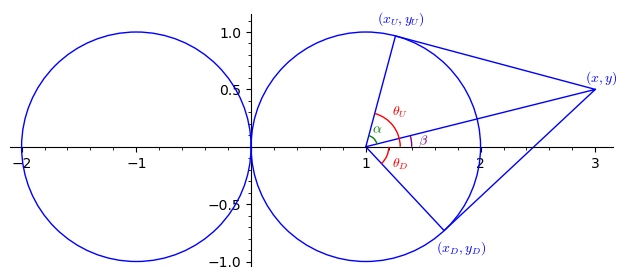

In [12]:
xp, yp = 3, 1/2
a = alpha.substitute(x==xp,y==yp)
b = beta.substitute(x==xp,y==yp)
tu = theta_U.substitute(x==xp,y==yp)
xu = x_U.substitute(x==xp,y==yp)
yu = y_U.substitute(x==xp,y==yp)
td = theta_D.substitute(x==xp,y==yp)
xd = x_D.substitute(x==xp,y==yp)
yd = y_D.substitute(x==xp,y==yp)
(circle((-1,0),1)+circle((1,0),1)
 +line([(1,0),(xu,yu),(xp,yp),(1,0),(xd,yd),(xp,yp)])
 +arc((1,0),0.3,sector=(0,tu),color="red")
 +text(r"$\theta_U$",(1.3,0.3),color="red")
 +arc((1,0),0.2,sector=(-td,0),color="red")
 +text(r"$\theta_D$",(1.3,-0.15),color="red")
 +arc((1,0),0.4,sector=(0,b),color="purple")
 +text(r"$\beta$",(1.5,0.05),color="purple")
 +arc((1,0),0.1,sector=(b,b+a),color="green")
 +text(r"$\alpha$",(1.1,0.15),color="green")
 +text(r"$(x,y)$",(xp+0.05,yp+0.1))
 +text(r"$(x_U,y_U)$",(xu+0.05,yu+0.15))
 +text(r"$(x_D,y_D)$",(xd+0.15,yd-0.15))
)

Plotting the quarter-loop

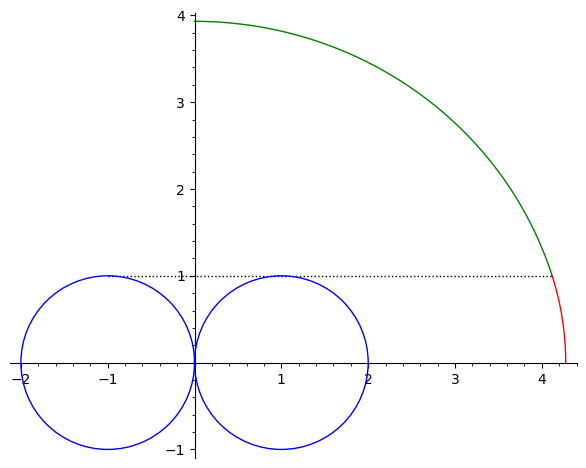

In [13]:
(circle((1,0),1)+circle((-1,0),1)
 +plot(lambda x: find_root(L1(x,y)-14,1,4), x, 0, x2, color="green")
 +plot(lambda x: find_root(L2(x,y)-14,0,5), x, x2, x3, color="red")
 +line([(-1,1),(x2,1)], color="black", linestyle="dotted")
)

And the area enclosed by the loop, which is four times the area under the quarter-loop,
is approximately 52.36.

In [14]:
4*(a1[0]+a2[0])

52.36472542139387

Additional thoughts
-------------------
It just occurred to me that the difference of 4 between the lengths of the string
in the fiddler and the extra credit was deliberately chosen to be equal to the
difference in the minimum lengths that can wrap around the disk and the two disks.

That means the parts of the loop where $-1 \le y \le 1$, in red in the figure above,
for the extra credit are arcs with the same radius of curvature as the radius of the
circular loop for the fiddler.

The parts of the loop where $y \ge 1$ or $y \le -1$, in green in the figure above,
are approximately ellipses.  In the limit where the radius of the two disks goes to
zero (while the centers of the disks remain separated by 2), the loop becomes an
ellipse and the circular portions at the left and right extremes vanish.

Both calculations of the radius agree.

In [15]:
x3-1, sqrt(1 + tan(t)^2)

(3.275326692795449, 3.2753266927954288)

And both calculations of the area agree.

In [16]:
a2[0], numerical_approx(integral(sqrt(1+tan(t)^2-x^2),x,tan(t),sqrt(1+tan(t)^2)))

(0.10476835565353763, 0.104768420799546)